# Modules

In [32]:
from pathlib import Path

In [35]:
Path('/localhome/home/mmmhr/EPS-Impact-Case-AI-Nowcasting/module')/'a.json'

PosixPath('/localhome/home/mmmhr/EPS-Impact-Case-AI-Nowcasting/module/a.json')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX = 8.69, 20.69
CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX = -23.45, -11.45
ZONE_SIZE = 3.0  # degrees

def generate_valid_zones(lat_min, lat_max, lon_min, lon_max, step):
    zones = {}
    zone_id = 1
    
    # Create coordinate grid
    lats = np.arange(lat_min, lat_max, step)
    lons = np.arange(lon_min, lon_max, step)
    
    for lat in lats:
        for lon in lons:
            lat_upper = lat + step
            lon_upper = lon + step

            # Skip zones that exceed domain bounds
            if lat_upper > lat_max or lon_upper > lon_max:
                continue
            
            zones[f"zone_{zone_id}"] = {
                "lat_min": round(lat, 2),
                "lat_max": round(lat_upper, 2),
                "lon_min": round(lon, 2),
                "lon_max": round(lon_upper, 2)
            }
            zone_id += 1
    
    return zones

# Generate zones
zones = generate_valid_zones(CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX,
                             CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX,
                             step=ZONE_SIZE)

# Print summary
for key, val in zones.items():
    print(f"{key}: {val}")


zone_1: {'lat_min': 8.69, 'lat_max': 11.69, 'lon_min': -23.45, 'lon_max': -20.45}
zone_2: {'lat_min': 8.69, 'lat_max': 11.69, 'lon_min': -20.45, 'lon_max': -17.45}
zone_3: {'lat_min': 8.69, 'lat_max': 11.69, 'lon_min': -17.45, 'lon_max': -14.45}
zone_4: {'lat_min': 8.69, 'lat_max': 11.69, 'lon_min': -14.45, 'lon_max': -11.45}
zone_5: {'lat_min': 11.69, 'lat_max': 14.69, 'lon_min': -23.45, 'lon_max': -20.45}
zone_6: {'lat_min': 11.69, 'lat_max': 14.69, 'lon_min': -20.45, 'lon_max': -17.45}
zone_7: {'lat_min': 11.69, 'lat_max': 14.69, 'lon_min': -17.45, 'lon_max': -14.45}
zone_8: {'lat_min': 11.69, 'lat_max': 14.69, 'lon_min': -14.45, 'lon_max': -11.45}
zone_9: {'lat_min': 14.69, 'lat_max': 17.69, 'lon_min': -23.45, 'lon_max': -20.45}
zone_10: {'lat_min': 14.69, 'lat_max': 17.69, 'lon_min': -20.45, 'lon_max': -17.45}
zone_11: {'lat_min': 14.69, 'lat_max': 17.69, 'lon_min': -17.45, 'lon_max': -14.45}
zone_12: {'lat_min': 14.69, 'lat_max': 17.69, 'lon_min': -14.45, 'lon_max': -11.45}
zone_

In [3]:
def plot_zones(zones):
    fig, ax = plt.subplots()
    for z in zones.values():
        rect = patches.Rectangle((z["lon_min"], z["lat_min"]),
                                 ZONE_SIZE, ZONE_SIZE,
                                 linewidth=1, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)
    ax.set_xlim(CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX)
    ax.set_ylim(CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX)
    ax.set_title("Zone Layout")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

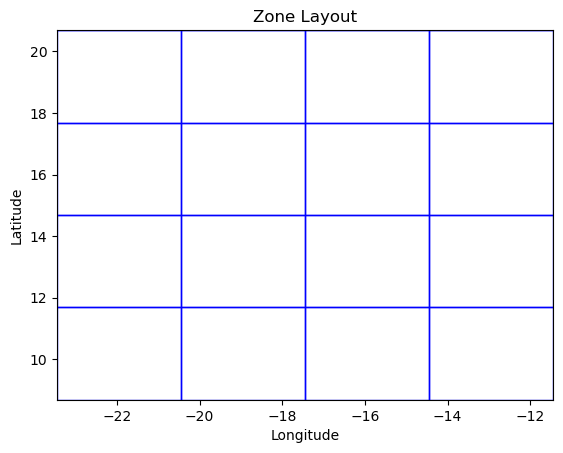

In [31]:
plot_zones(zones)

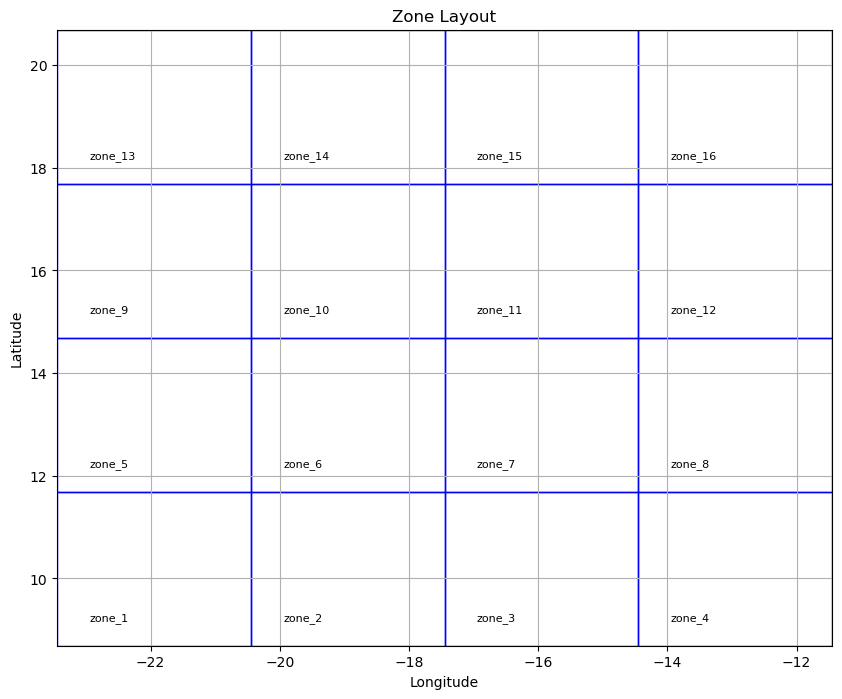

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 8))

for zone_name, bounds in zones.items():
    rect = patches.Rectangle(
        (bounds["lon_min"], bounds["lat_min"]),
        bounds["lon_max"] - bounds["lon_min"],
        bounds["lat_max"] - bounds["lat_min"],
        linewidth=1,
        edgecolor="blue",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(
        bounds["lon_min"] + 0.5,
        bounds["lat_min"] + 0.5,
        zone_name,
        fontsize=8,
        color="black"
    )

ax.set_xlim(CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX)
ax.set_ylim(CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Zone Layout")
plt.grid(True)
plt.show()
